In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

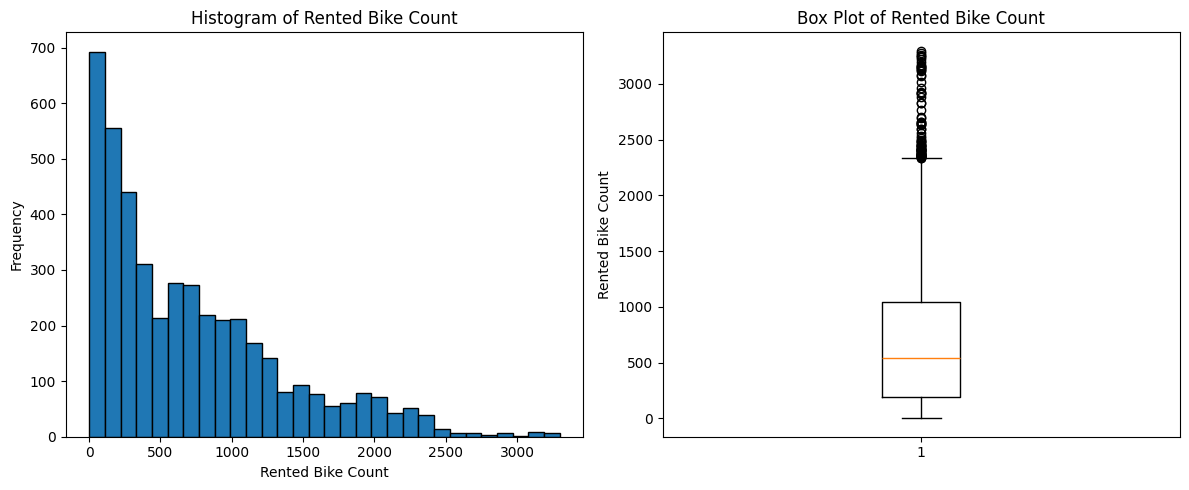

Training set: 3091 samples (70%)
Test set:     1325 samples (30%)
R²:   0.4435
RMSE: 481.2470
MAE:  344.9291
CV:   67.38%


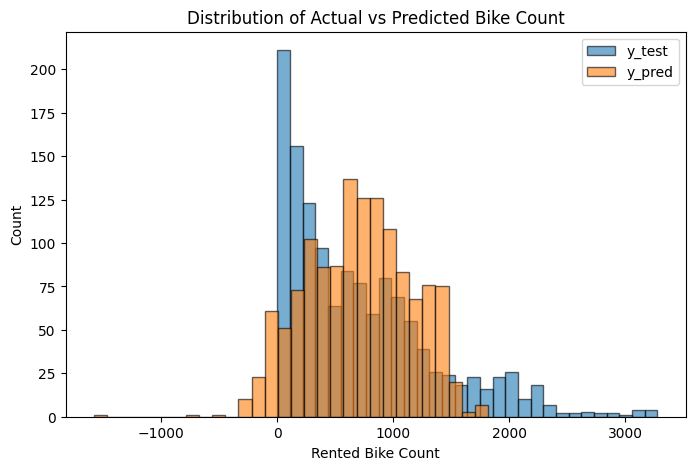

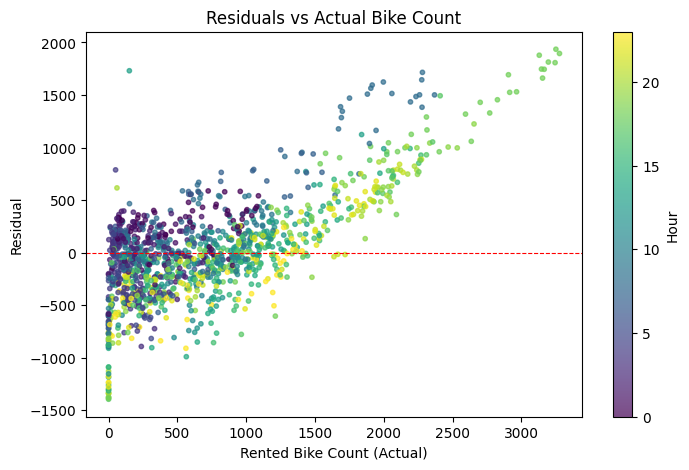

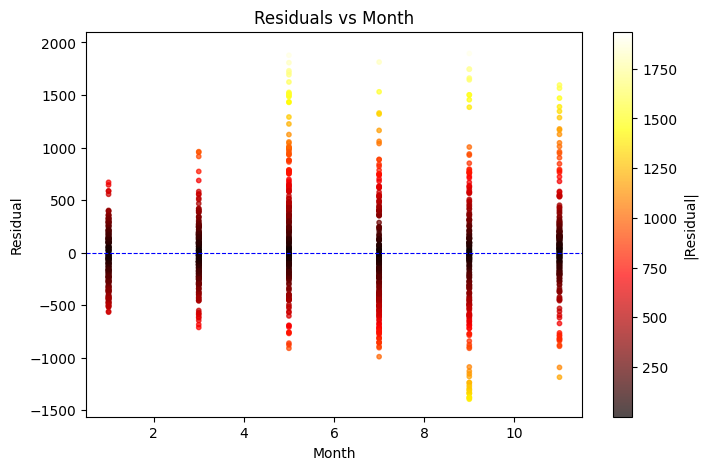

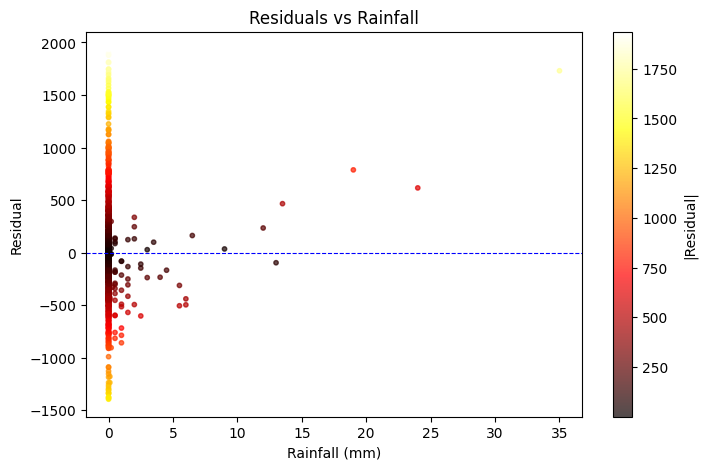

In [2]:
# Task  A1

df = pd.read_csv('SeoulBikeData_mod.csv')
df.describe()


# Histogram and Box Plot of Rented Bike Count
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['Rented Bike Count'], bins=30, edgecolor='black')
axes[0].set_xlabel('Rented Bike Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Rented Bike Count')

axes[1].boxplot(df['Rented Bike Count'], vert=True)
axes[1].set_ylabel('Rented Bike Count')
axes[1].set_title('Box Plot of Rented Bike Count')

plt.tight_layout()
plt.show()

# Design feature matrix and target column

X = df.drop(columns=['Rented Bike Count'])
y = df['Rented Bike Count']

#  Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.0f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.0f}%)")

# Train linear regression model

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and residuals

y_pred = model.predict(X_test)
resid = y_test - y_pred

# Metrics

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
cv = (rmse / y_test.mean()) * 100

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"CV:   {cv:.2f}%")

# Diagnostic plots

# Overlaid histograms of both y_test (actual) and y_pred (prediction)
plt.figure(figsize=(8, 5))
plt.hist(y_test, bins=30, alpha=0.6, label='y_test', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.6, label='y_pred', edgecolor='black')
plt.xlabel('Rented Bike Count')
plt.ylabel('Count')
plt.title('Distribution of Actual vs Predicted Bike Count')
plt.legend()
plt.show()

# Residuals plotted against y_test coloured by Hour
plt.figure(figsize=(8, 5))
sc = plt.scatter(y_test, resid, c=X_test['Hour'], cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='Hour')
plt.axhline(y=0, color='r', linestyle='--', linewidth=0.8)
plt.xlabel('Rented Bike Count (Actual)')
plt.ylabel('Residual')
plt.title('Residuals vs Actual Bike Count')
plt.show()

# Residuals plotted against Month coloured by absolute value of residual
plt.figure(figsize=(8, 5))
sc = plt.scatter(X_test['Month'], resid, c=np.abs(resid), cmap='hot', s=10, alpha=0.7)
plt.colorbar(sc, label='|Residual|')
plt.axhline(y=0, color='b', linestyle='--', linewidth=0.8)
plt.xlabel('Month')
plt.ylabel('Residual')
plt.title('Residuals vs Month')
plt.show()

# Residuals plotted against Rainfall coloured by absolute value of residual
plt.figure(figsize=(8, 5))
sc = plt.scatter(X_test['Rainfall(mm)'], resid, c=np.abs(resid), cmap='hot', s=10, alpha=0.7)
plt.colorbar(sc, label='|Residual|')
plt.axhline(y=0, color='b', linestyle='--', linewidth=0.8)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Residual')
plt.title('Residuals vs Rainfall')
plt.show()

We used a 70/30 train/test split (ie test_size=0.3)

**Metric Comparison:**
According to Table 4 in the provided Soeul Bike Paper, the Linear Regression model that had been tested on the original dataset achieved an $R^2$ of 0.55, a RMSE of 427.71, a MAE of 322.32, and a CV of 61.03%.

When we applied the linear regression model to our modified dataset, the results were a little but worse across all of these metrics, with an $R^2$ of 0.4435, a RMSE of 481.2470, a MAE of 344.9291, and a CV of 67.38%.

This slightly worse performance is expected. The paper states that the usage count is not linearly related to any of the independent variables, which limits the model. Additionally, our dataset was modified to remove categorical variables and reduce the data span, which removed some predictive features from the model.

**Analysis of Diagnostic Plots:**
* **Distribution of Actual vs Predicted Bike Count:** The histogram of the actual test data (`y_test`) shows a significant right skew, this means that there are several instances of low bike rentals and less instances of very high rentals. Our predicted values (`y_pred`) are closer to being normally distributed, failing to capture counts on the extreme ends (both high and low).

* **Residuals vs Actual Bike Count (colored by Hour):** When the actual rented bike count increases, the spread of the residuals also increases. This indicates a non-constant variance in the errors made by our model. As the original paper notes about the linear regression model, the residuals are not well spread out around the horizontal axis. The color mapping demonstrates that errors vary significantly depending on the time of day, with peak hours generating more significanr prediction errors.

* **Residuals vs Month:** This plot shows the way in which prediction errors are distributed across the different months. The absolute error likely highlights that warmer summer months experience higher variance and greater overall demand, which results in much greater prediction residuals in comparison to winter months.

* **Residuals vs Rainfall:** The majority of the data points are close to zero rainfall. Consequently, for days with zero rainfall there is a large vertical spread in residuals. As rainfall increases, the spread of residuals gets more compressed, mainly due to the fact that heavy rain leads to a reduction in bike usage, so the model makes less erro.

Iteration     0: J = 8.859615, m = -0.3671, c = 1.8535
Iteration   500: J = 0.337318, m = 1.6060, c = 0.2291
Iteration  1000: J = 0.232592, m = 1.8817, c = -0.3978
Iteration  1500: J = 0.223157, m = 1.9645, c = -0.5860
Iteration  2000: J = 0.222306, m = 1.9893, c = -0.6424
Iteration  2500: J = 0.222230, m = 1.9968, c = -0.6594
Iteration  3000: J = 0.222223, m = 1.9990, c = -0.6645
Iteration  3500: J = 0.222222, m = 1.9997, c = -0.6660
Iteration  4000: J = 0.222222, m = 1.9999, c = -0.6665
Iteration  4500: J = 0.222222, m = 2.0000, c = -0.6666
Iteration  4999: J = 0.222222, m = 2.0000, c = -0.6666

Optimal parameters: m = 2.0000, c = -0.6666


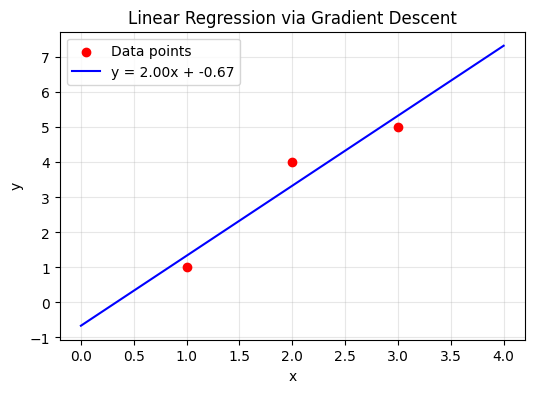


Learning rate of 0.001
Iteration     0: J = 10.610918, m = -0.4884, c = 1.8079
Iteration   500: J = 1.231140, m = 0.8290, c = 1.9832
Iteration  1000: J = 1.015428, m = 0.9656, c = 1.6848
Iteration  1500: J = 0.845916, m = 1.0828, c = 1.4184
Iteration  2000: J = 0.712630, m = 1.1867, c = 1.1823
Iteration  2500: J = 0.607828, m = 1.2788, c = 0.9728
Iteration  3000: J = 0.525423, m = 1.3605, c = 0.7871
Iteration  3500: J = 0.460627, m = 1.4329, c = 0.6225
Iteration  4000: J = 0.409679, m = 1.4971, c = 0.4765
Iteration  4500: J = 0.369619, m = 1.5541, c = 0.3470
Iteration  4999: J = 0.338175, m = 1.6045, c = 0.2324

Learning rate of 0.05
Iteration     0: J = 3.321900, m = 0.1718, c = 2.0563
Iteration   100: J = 0.333801, m = 1.6120, c = 0.2153
Iteration   200: J = 0.232159, m = 1.8842, c = -0.4035
Iteration   300: J = 0.223107, m = 1.9655, c = -0.5881
Iteration   400: J = 0.222301, m = 1.9897, c = -0.6432
Iteration   500: J = 0.222229, m = 1.9969, c = -0.6597
Iteration   600: J = 0.222223

(-456847357.833506, -200967938.33770442)

In [4]:
# Task A2

# Gradient descent model

def cost_J(m, c):
    return (14*m**2 + 12*c*m - 48*m + 3*c**2 - 20*c + 42) / 3

def dJ_dm(m, c):
    return (28*m + 12*c - 48) / 3

def dJ_dc(m, c):
    return (12*m + 6*c - 20) / 3

def model1(alpha, num_iterations):
    """
    alpha represents the learning rate
    num_iterations represents the number of gradient descent steps

    the function returns optimised parameters m and c
    """
    np.random.seed(42)
    m = np.random.uniform(-2, 2)
    c = np.random.uniform(-2, 2)

    for i in range(num_iterations):
        grad_m = dJ_dm(m, c)
        grad_c = dJ_dc(m, c)
        m -= alpha * grad_m
        c -= alpha * grad_c

        if i % (num_iterations // 10) == 0 or i == num_iterations - 1:
            print(f"Iteration {i:5d}: J = {cost_J(m, c):.6f}, m = {m:.4f}, c = {c:.4f}")

    return m, c

# Run with a learning rate of 0.01 and 5000 iterations
m_opt, c_opt = model1(alpha=0.01, num_iterations=5000)
print(f"\nOptimal parameters: m = {m_opt:.4f}, c = {c_opt:.4f}")

# Plot data and fitted line

x_data = np.array([1, 2, 3])
y_data = np.array([1, 4, 5])

x_line = np.linspace(0, 4, 100)
y_line = m_opt * x_line + c_opt

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, color='red', zorder=5, label='Data points')
plt.plot(x_line, y_line, 'b-', label=f'y = {m_opt:.2f}x + {c_opt:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression via Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Explore different learning rates and iteration numbers

print("\nLearning rate of 0.001")
model1(alpha=0.001, num_iterations=5000)

print("\nLearning rate of 0.05")
model1(alpha=0.05, num_iterations=1000)

print("\nLearning rate of 0.2")
model1(alpha=0.2, num_iterations=100)


**1. Derivation of the Cost Function, $J$**
We have three data points:
$(1,1), (2,4), (3,5)$.

The linear model is defined as $\hat{y}_i = m x_i + c$.

The loss for a given point is $L = (\hat{y}_i - y_i)^2 = (m x_i + c - y_i)^2$.

The Mean Squared Error (MSE) cost function $J$ is the mean of these losses:

$$J = \frac{1}{3} \sum_{i=1}^{3} (m x_i + c - y_i)^2$$

Expanding this for each of the three points:

For $x=1, y=1$: $(m(1) + c - 1)^2 = m^2 + c^2 + 1 + 2mc - 2m - 2c$

For $x=2, y=4$: $(m(2) + c - 4)^2 = 4m^2 + c^2 + 16 + 4mc - 16m - 8c$

For $x=3, y=5$: $(m(3) + c - 5)^2 = 9m^2 + c^2 + 25 + 6mc - 30m - 10c$

Summing expanded terms together:

* $m^2$ terms:
$1m^2 + 4m^2 + 9m^2 = 14m^2$
* $c^2$ terms:
$1c^2 + 1c^2 + 1c^2 = 3c^2$
* $mc$ terms:
$2mc + 4mc + 6mc = 12mc$
* $m$ terms:
$-2m - 16m - 30m = -48m$
* $c$ terms:
$-2c - 8c - 10c = -20c$
* Constants: $1 + 16 + 25 = 42$

Dividing entire sum by 3 gives the final cost function:
$$J = \frac{14m^2 + 12cm - 48m + 3c^2 - 20c + 42}{3}$$

**2. Partial Derivatives of the Cost Function**

To find the gradient for the descent steps, we find the partial derivatives of $J$ with respect to $m$ and $c$ using:

Partial derivative with respect to $m$:

$$\frac{\partial J}{\partial m} = \frac{1}{3}(28m + 12c - 48)$$

Partial derivative with respect to $c$:

$$\frac{\partial J}{\partial c} = \frac{1}{3}(12m + 6c - 20)$$

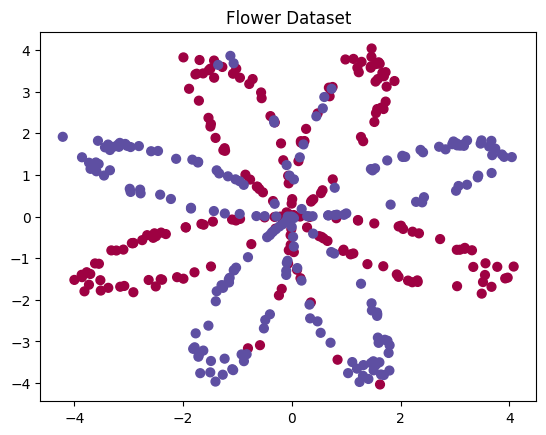

Cost after iteration 0: 0.693769
Cost after iteration 1000: 0.673146
Cost after iteration 2000: 0.673146
Cost after iteration 3000: 0.673146
Cost after iteration 4000: 0.673146
Cost after iteration 5000: 0.673146
Cost after iteration 6000: 0.673146
Cost after iteration 7000: 0.673146
Cost after iteration 8000: 0.673146
Cost after iteration 9000: 0.673146


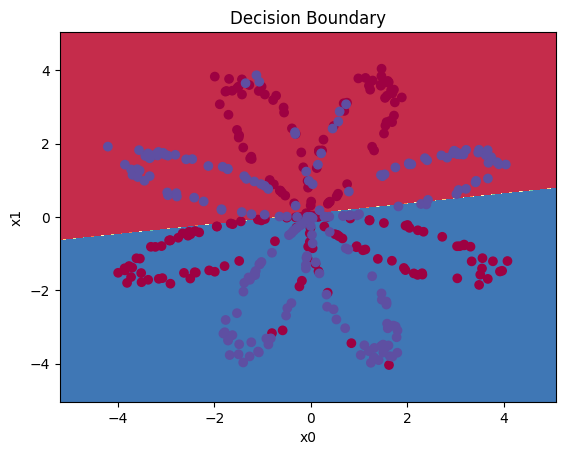

Accuracy of logistic regression: 47%


In [5]:
# Task A3

# Create flower dataset

def load_flower_dataset():
    np.random.seed(1)
    m = 400
    N = int(m / 2)
    D = 2
    X = np.zeros((m, D))
    y = np.zeros((m, 1), dtype='uint8')
    a = 4
    for j in range(2):
        ix = range(N * j, N * (j + 1))
        t = np.linspace(j * 3.12, (j + 1) * 3.12, N) + np.random.randn(N) * 0.2
        r = a * np.sin(4 * t) + np.random.randn(N) * 0.2
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    return X.T, y.T

X, y = load_flower_dataset()
plt.scatter(X[0, :], X[1, :], c=y.ravel(), s=40, cmap=plt.cm.Spectral)
plt.title('Flower Dataset')
plt.show()

# Helper functions

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def initialize_parameters(n_X, n_y):
    W = np.random.randn(n_y, n_X) * 0.01
    b = np.zeros((n_y, 1))
    return {"W": W, "b": b}

def forward_propagation(X, parameters):
    W = parameters["W"]
    b = parameters["b"]
    z = np.dot(W, X) + b
    y_hat = sigmoid(z)
    return y_hat, z

def compute_cost(y_hat, y):
    m = y.shape[1]
    loss = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    cost = float(np.sum(loss) / m)
    return cost

def backward_propagation(parameters, y_hat, X, y):
    m = y.shape[1]
    W = parameters["W"]
    dz = y_hat - y
    dW = np.dot(dz, X.T) / m
    db = np.sum(dz, axis=1, keepdims=True) / m
    return {"dW": dW, "db": db}

def update_parameters(parameters, grads, learning_rate=1.2):
    W = copy.deepcopy(parameters["W"])
    b = copy.deepcopy(parameters["b"])
    W -= learning_rate * grads["dW"]
    b -= learning_rate * grads["db"]
    return {"W": W, "b": b}

# Logistic regression model

def model(X, y, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_X = X.shape[0]
    n_y = y.shape[0]
    parameters = initialize_parameters(n_X, n_y)

    for i in range(num_iterations):
        y_hat, z = forward_propagation(X, parameters)
        cost = compute_cost(y_hat, y)
        grads = backward_propagation(parameters, y_hat, X, y)
        parameters = update_parameters(parameters, grads, learning_rate=1.2)

        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.6f}")

    return parameters

def predict(learned_parameters, X):
    y_hat, _ = forward_propagation(X, learned_parameters)
    predictions = (y_hat > 0.5).astype(int)
    return predictions

# Decision boundary plotter

def plot_decision_boundary(learned_parameters, X, y):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = predict(learned_parameters, np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap=plt.cm.Spectral)
    plt.title("Decision Boundary")
    plt.show()

# Train and evaluate

learned_parameters = model(X, y, num_iterations=10000, print_cost=True)
plot_decision_boundary(learned_parameters, X, y)

predictions = predict(learned_parameters, X)
accuracy = float(np.mean(predictions == y) * 100)
print(f'Accuracy of logistic regression: {accuracy:.0f}%')

Cost after iteration 0: 0.693162
Cost after iteration 1000: 0.258625
Cost after iteration 2000: 0.239334
Cost after iteration 3000: 0.230802
Cost after iteration 4000: 0.225528
Cost after iteration 5000: 0.221845
Cost after iteration 6000: 0.219094
Cost after iteration 7000: 0.220619
Cost after iteration 8000: 0.219398
Cost after iteration 9000: 0.218482


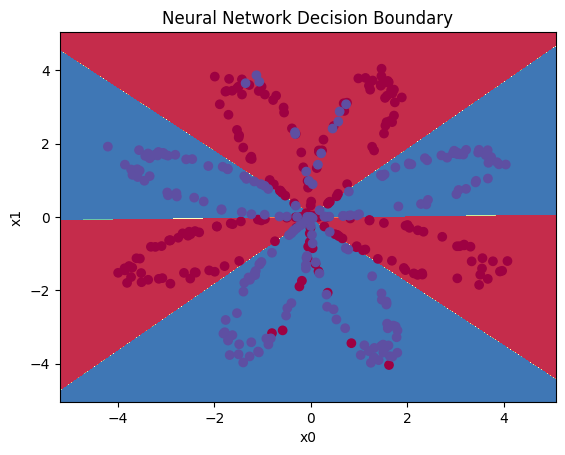

Accuracy of neural network: 91% (percentage of correctly labelled datapoints)


In [6]:
# Task A4

def initialize_parameters_nn(n_X, n_h, n_y):
    np.random.seed(3)
    W = np.random.randn(n_h, n_X) * 0.01   # hidden layer weights
    b = np.zeros((n_h, 1))                   # hidden layer biases
    T = np.random.randn(n_y, n_h) * 0.01    # output layer weights
    c = np.zeros((n_y, 1))                   # output layer biases
    return {"W": W, "b": b, "T": T, "c": c}

def forward_propagation_nn(X, parameters):
    W = parameters["W"]
    b = parameters["b"]
    T = parameters["T"]
    c = parameters["c"]

    z = np.dot(W, X) + b       # hidden layer linear
    a = np.tanh(z)              # hidden layer activation
    v = np.dot(T, a) + c       # output layer linear
    y_hat = sigmoid(v)          # output layer activation

    cache = {"z": z, "a": a, "v": v, "y_hat": y_hat}
    return y_hat, cache

def backward_propagation_nn(parameters, cache, X, y):
    m = y.shape[1]
    T = parameters["T"]
    a = cache["a"]
    y_hat = cache["y_hat"]

    dv = y_hat - y
    dT = np.dot(dv, a.T) / m
    dc = np.sum(dv, axis=1, keepdims=True) / m
    dz = np.dot(T.T, dv) * (1 - np.power(a, 2))
    dW = np.dot(dz, X.T) / m
    db = np.sum(dz, axis=1, keepdims=True) / m

    return {"dW": dW, "db": db, "dT": dT, "dc": dc}

def update_parameters_nn(parameters, grads, learning_rate=1.2):
    W = copy.deepcopy(parameters["W"]) - learning_rate * grads["dW"]
    b = copy.deepcopy(parameters["b"]) - learning_rate * grads["db"]
    T = copy.deepcopy(parameters["T"]) - learning_rate * grads["dT"]
    c = copy.deepcopy(parameters["c"]) - learning_rate * grads["dc"]
    return {"W": W, "b": b, "T": T, "c": c}

def model_nn(X, y, n_h=4, num_iterations=10000, print_cost=False):
    np.random.seed(3)
    n_X = X.shape[0]
    n_y = y.shape[0]
    parameters = initialize_parameters_nn(n_X, n_h, n_y)

    for i in range(num_iterations):
        y_hat, cache = forward_propagation_nn(X, parameters)
        cost = compute_cost(y_hat, y)
        grads = backward_propagation_nn(parameters, cache, X, y)
        parameters = update_parameters_nn(parameters, grads, learning_rate=1.2)

        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost:.6f}")

    return parameters

def predict_nn(learned_parameters, X):
    y_hat, _ = forward_propagation_nn(X, learned_parameters)
    predictions = (y_hat > 0.5).astype(int)
    return predictions

# NN decision boundary plot function

def plot_decision_boundary_nn(learned_parameters, X, y):
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = predict_nn(learned_parameters, np.c_[xx.ravel(), yy.ravel()].T)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x1')
    plt.xlabel('x0')
    plt.scatter(X[0, :], X[1, :], c=y.ravel(), cmap=plt.cm.Spectral)
    plt.title("Neural Network Decision Boundary")
    plt.show()

# Train and evaluate

learned_parameters_nn = model_nn(X, y, n_h=4, num_iterations=10000, print_cost=True)
plot_decision_boundary_nn(learned_parameters_nn, X, y)

predictions_nn = predict_nn(learned_parameters_nn, X)
accuracy_nn = float(np.mean(predictions_nn == y) * 100)
print(f'Accuracy of neural network: {accuracy_nn:.0f}% (percentage of correctly labelled datapoints)')

Comparison between models used inA3 (Logistic Regression) and A4 (Neural Network)

The logistic regression model achieves approximately 47% accuracy when evaluated on the flower dataset, the primary reason for this performance is the fact that it can only learn linear decision boundaries (but the data is extremely non-linear).

The neural network with one hidden layer achieves approximately 91% accuracy. This improvement in comparison the logistic regression model is due to the fact that the hyperbolic tangent activation function allows the model to learn non-linear patterns such as that in this dataset.